# 01 — Exploratory Data Analysis

This notebook performs EDA on daily BTC/USDT price data.
It covers:
- Price evolution and rolling statistics
- Returns distribution and stationarity tests
- Volatility regime analysis
- Volume analysis
- Autocorrelation structure

In [14]:
import sys, os

# src/notebooks/ → src/ → Diplom_work/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

from src.data.download import load_or_download
from src.data.validation import validate_and_clean_data

df_raw     = load_or_download()
df_cleaned = validate_and_clean_data(df_raw)

print(f'Dataset: {len(df_cleaned):,} rows  |  '
      f'{df_cleaned["timestamp"].min().date()} → {df_cleaned["timestamp"].max().date()}')

FETCHING BITCOIN DATA FROM BINANCE
Symbol   : BTCUSDT
Interval : 1d  (DAILY – better for ML)
Start    : 2020-01-01

Downloading...

✅ Download complete!
   Total days  : 2,260
   Date range  : 2020-01-01 00:00:00 → 2026-03-09 00:00:00
✅ Data saved to bitcoin_daily_data.csv
DATA INTEGRITY AUDIT
Initial rows : 2,260
Date range   : 2020-01-01 00:00:00 → 2026-03-09 00:00:00
OHLC relationships valid.
No missing daily timestamps detected.

Return distribution summary:
count    2259.000000
mean        0.001528
std         0.032368
min        -0.395048
25%        -0.012907
50%         0.000329
75%         0.015136
max         0.195361
Name: returns, dtype: float64
Final rows : 2,260
Dataset: 2,260 rows  |  2020-01-01 → 2026-03-09


## 1. Price Evolution

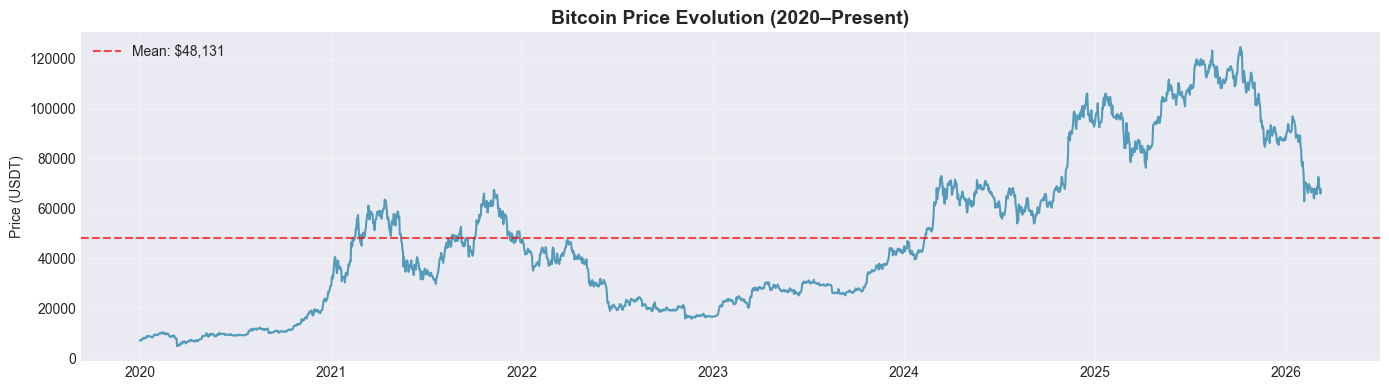

In [15]:
df = df_cleaned.copy()
df['returns']    = df['close'].pct_change()
df['log_returns']= np.log(df['close'] / df['close'].shift(1))
df['volatility'] = df['returns'].rolling(30).std() * np.sqrt(365)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], df['close'], color='#2E86AB', linewidth=1.5, alpha=0.8)
ax.set_title('Bitcoin Price Evolution (2020–Present)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USDT)')
ax.axhline(y=df['close'].mean(), color='red', linestyle='--',
           label=f"Mean: ${df['close'].mean():,.0f}", alpha=0.7)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Returns Distribution

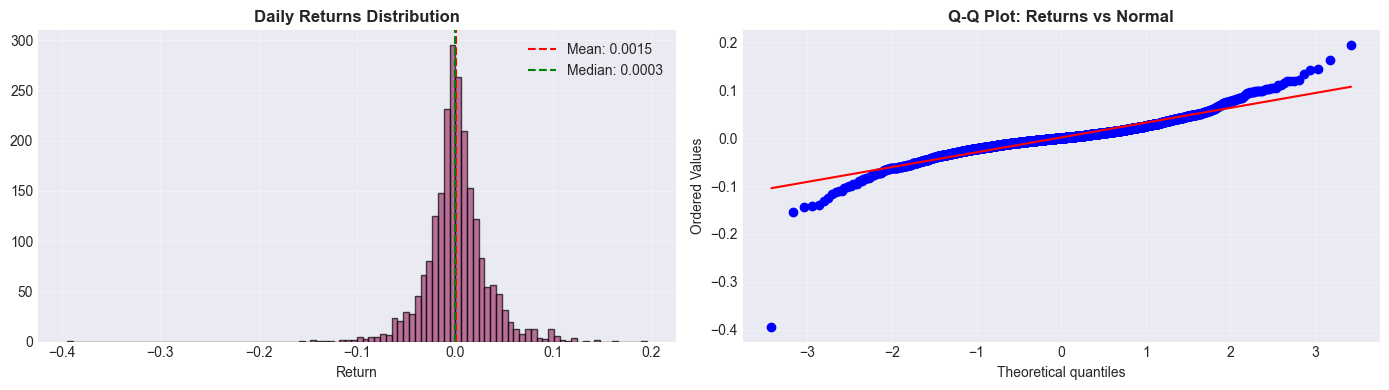

Skewness : -0.5648
Kurtosis : 12.9143  (>3 = fat tails)


In [16]:
returns_clean = df['returns'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(returns_clean, bins=100, color='#A23B72', alpha=0.7, edgecolor='black')
axes[0].axvline(returns_clean.mean(),   color='red',   linestyle='--',
                label=f'Mean: {returns_clean.mean():.4f}')
axes[0].axvline(returns_clean.median(), color='green', linestyle='--',
                label=f'Median: {returns_clean.median():.4f}')
axes[0].set_title('Daily Returns Distribution', fontweight='bold')
axes[0].set_xlabel('Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

stats.probplot(returns_clean, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Returns vs Normal', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Skewness : {returns_clean.skew():.4f}')
print(f'Kurtosis : {returns_clean.kurtosis():.4f}  (>3 = fat tails)')

## 3. Rolling Volatility & Volume

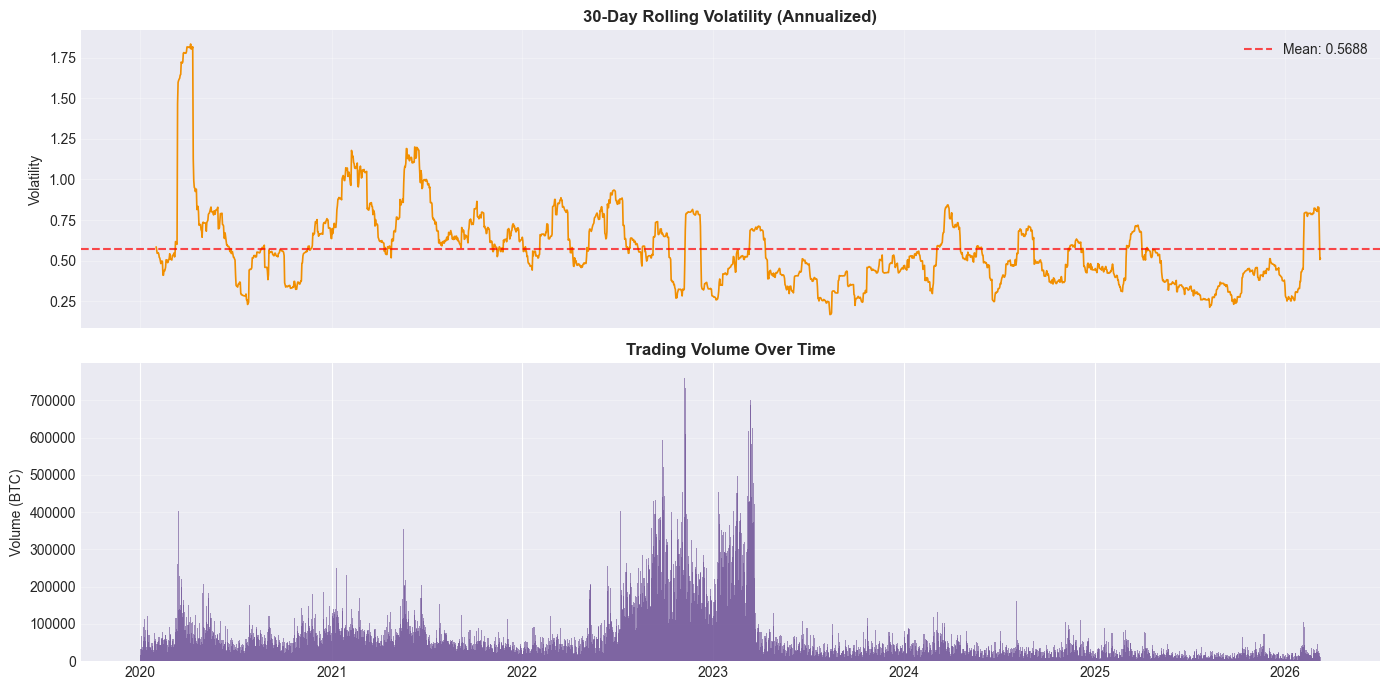

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['timestamp'], df['volatility'], color='#F18F01', linewidth=1.2)
axes[0].axhline(df['volatility'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['volatility'].mean():.4f}", alpha=0.7)
axes[0].set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
axes[0].set_ylabel('Volatility')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(df['timestamp'], df['volume'], width=2, color='#6A4C93', alpha=0.6)
axes[1].set_title('Trading Volume Over Time', fontweight='bold')
axes[1].set_ylabel('Volume (BTC)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Autocorrelation

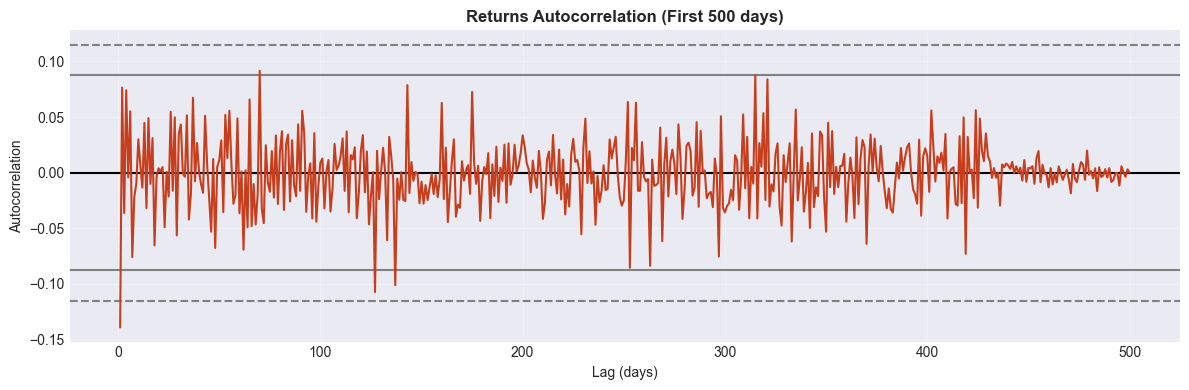

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(returns_clean[:500], ax=ax, color='#C73E1D')
ax.set_title('Returns Autocorrelation (First 500 days)', fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Statistical Summary

In [19]:
# Directional counts
up_moves  = (returns_clean > 0).sum()
down_moves= (returns_clean < 0).sum()
neutral   = (returns_clean == 0).sum()
total     = len(returns_clean)

print('Directional Analysis')
print(f'  Up days   : {up_moves:,} ({up_moves/total*100:.2f}%)')
print(f'  Down days : {down_moves:,} ({down_moves/total*100:.2f}%)')
print(f'  Neutral   : {neutral:,} ({neutral/total*100:.2f}%)')
print(f'  Baseline to beat: {max(up_moves, down_moves)/total*100:.2f}%')

# Stationarity
adf = adfuller(returns_clean.dropna())
print(f'\nADF Test on Returns')
print(f'  Statistic : {adf[0]:.4f}')
print(f'  p-value   : {adf[1]:.6f}')
print(f'  => {"STATIONARY ✅" if adf[1] < 0.05 else "NOT stationary ⚠️"}')

Directional Analysis
  Up days   : 1,148 (50.82%)
  Down days : 1,111 (49.18%)
  Neutral   : 0 (0.00%)
  Baseline to beat: 50.82%

ADF Test on Returns
  Statistic : -22.8718
  p-value   : 0.000000
  => STATIONARY ✅
